DSCI 552 Homework 4

Name: Brynn Dafoe GitHub Username: brynndafoe02 USD ID: 3109-6692-10

HOMEWORK 3 PORTION NEEDED FOR HOMEWORK 4:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

from itertools import combinations
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from pathlib import Path
import re

In [2]:
# I manually edited bending2 dataset4 to have the delimiter be "," since it was causing issues
path_to_AReM = Path("../data/AReM")
column_names = ["time", "avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]

training_dfs = {}
testing_dfs = {}

for data_dir in path_to_AReM.iterdir():
    if data_dir.is_dir(): # want to skip the .pdfs
        dir_name = data_dir.name
            
        for file in data_dir.iterdir():
            if not file.is_file():
                continue
                # added this becasue for some reason it was reading .ipynb_checkpoints folder (idk how or why)
            
            file_name = Path(file).stem
            file_num = int("".join(re.findall(r"\d", file_name)))

            key = f"{dir_name}_{file_name}"
            
            if (dir_name == "bending1") or (dir_name == "bending2"):
                df = pd.read_csv(file, skiprows=5, names=column_names)
                
                if (file_num == 1) or (file_num == 2):
                    testing_dfs[key] = df
                else:
                    training_dfs[key] = df
            else: 
                df = pd.read_csv(file, skiprows=5, names=column_names)
                
                if (file_num == 1) or (file_num == 2) or (file_num == 3):
                    testing_dfs[key] = df
                else:
                    training_dfs[key] = df

In [3]:
columns_six = column_names[1:]

training_features = []
# 69 rows x 42 columns
# looks like:
    # [ {dirfilename : name, min1 : x, max1 : x, mean1 : x, median1 : x, stddev : x,
    # firstQ1 : x, thirdQ1 : x, ........, thirdQ6 : x}, {}, {}, ..., {} ]
    # for each of the 6 features in files: 
        # avg_rss12, var_rss12, avg_rss13, var_rss13, vg_rss23, ar_rss23

for dirfile1, its_df1 in training_dfs.items():
    a_instance = {}
    a_instance["dirfile_name"] = dirfile1 # to keep track of where the numbers are coming from

    for i, a_column in enumerate(columns_six, start=1):
        a_instance[f"min_{i}"] = its_df1[a_column].min()
        a_instance[f"max_{i}"] = its_df1[a_column].max()
        a_instance[f"mean_{i}"] = its_df1[a_column].mean()
        a_instance[f"median_{i}"] = its_df1[a_column].median()
        a_instance[f"std_dev_{i}"] = its_df1[a_column].std()
        a_instance[f"first_quart_{i}"] = its_df1[a_column].quantile(0.25)
        a_instance[f"third_quart_{i}"] = its_df1[a_column].quantile(0.75)

    training_features.append(a_instance)

train_feat_df = pd.DataFrame(training_features)


In [4]:
testing_features = []
# 19 rows x 42 columns

for dirfile2, its_df2 in testing_dfs.items():
    b_instance = {}
    b_instance["dirfile_name"] = dirfile2

    for j, b_column in enumerate(columns_six, start=1):
        b_instance[f"min_{j}"] = its_df2[b_column].min()
        b_instance[f"max_{j}"] = its_df2[b_column].max()
        b_instance[f"mean_{j}"] = its_df2[b_column].mean()
        b_instance[f"median_{j}"] = its_df2[b_column].median()
        b_instance[f"std_dev_{j}"] = its_df2[b_column].std()
        b_instance[f"first_quart_{j}"] = its_df2[b_column].quantile(0.25)
        b_instance[f"third_quart_{j}"] = its_df2[b_column].quantile(0.75)

    testing_features.append(b_instance)

test_feat_df = pd.DataFrame(testing_features)


In [5]:
all_features = training_features + testing_features
all_features_df = pd.DataFrame(all_features)
af_df = all_features_df.drop(columns=["dirfile_name"])
# ALL time-domain features for each original feature
std_of_features = af_df.std()

In [6]:
boostrap_results = []

for a_column in af_df.columns:
    one_feat = {}
    one_feat["feat"] = a_column
    one_feat["std_dev"] = std_of_features[a_column]

    boostrap_samples = []

    for _ in range(1000):
        boostrap_sample = af_df[a_column].sample(frac=1.0, replace=True)
        boostrap_sample_std = boostrap_sample.std()
        boostrap_samples.append(boostrap_sample_std)

    bootstrap_series = pd.Series(boostrap_samples)

    left_tail = bootstrap_series.quantile(0.05)
    right_tail = bootstrap_series.quantile(0.95)

    one_feat["left_tail"] = left_tail
    one_feat["right_tail"] = right_tail

    boostrap_results.append(one_feat)


# for result in boostrap_results:
#     for key, value in result.items():
#         print(f"{key} -> {value}")
#     print("\n")

IMPORTANT:
- I found an error in my original pd.read_csv section (the first section after the imports), specifically with bending2 dataset4 that ended up changing the bootstrap results. After reviewing the changes in the results I STILL find that Max, Median, and Third Quartile are the three strongest features, but I just wanted to point out that my boostrap results changed from HW3 to HW4 because I did not catch this error in HW3. I was getting nans in the current 2.a.i part that made me have to go back and see what was wrong.

In HW3, I chose Max, Median, and Third Quartile to be the three features.

HOMEWORK 4 SECTION:

Question 2.a.i
- Assume that you want to use the training set to classify bending from other activities, ie: you have a binary classification problem
- Depict scatter plots of the features you specified in 1.c.iv extracted from time series 1, 2, and 6 of each instance, and use color to distinguish bending vs. other activities
- (See p. 129 of TB)
- (Some LogReg packages have built in L2 regularization -> to remove the effect of L2 regularization, set lambda = 0 or set the budget C -> infinity (ie: very large value))
- (Can repeat this experiment with other features as well as with time series 3, 4, and 5 in each instance)

In [7]:
# Features needed:
    # max_1, max_2, max_6
    # median_1, median_2, median_6
    # third_quart_1, third_quart_2, third_quart_6

# train_feat_df -> {dirfilename : name, min1 : x, etc...} -> 69 rows
    # bending1, bending2 -> bending
    # cycling, lying, sitting, standing, walking -> other

# scatterplot: bending = red, other = blue
            #  x-axis = 1 feature (like max_1)
            #  y-axis = 1 feature (like max_2)
# 3 scatterplots per feature:
    # maxes: max_1 + max_2 / max_1 + max_6 / max_2 + max_6
    # medians: median_1 + median_2 / median_1 + median_6 / median_2 + median_6
    # third_quarts: third_quart_1 + third_quart_2 / third_quart_1 + third_quart_6 / third_quart_2 + third_quart_6

max_1s = {"bending" : [], "other" : []}
max_2s = {"bending" : [], "other" : []}
max_6s = {"bending" : [], "other" : []}

median_1s = {"bending" : [], "other" : []}
median_2s = {"bending" : [], "other" : []}
median_6s = {"bending" : [], "other" : []}

thirdQ_1s = {"bending" : [], "other" : []}
thirdQ_2s = {"bending" : [], "other" : []}
thirdQ_6s = {"bending" : [], "other" : []}

for _, row in train_feat_df.iterrows(): # _ because we don't care about index, just go through entire thing
    
    file_name = row["dirfile_name"]
    
    if "bend" in file_name:
        activity = "bending"
    else:
        activity = "other"
        
    max_1s[activity].append(row["max_1"])
    max_2s[activity].append(row["max_2"])
    max_6s[activity].append(row["max_6"])

    median_1s[activity].append(row["median_1"])
    median_2s[activity].append(row["median_2"])
    median_6s[activity].append(row["median_6"])

    thirdQ_1s[activity].append(row["third_quart_1"])
    thirdQ_2s[activity].append(row["third_quart_2"])
    thirdQ_6s[activity].append(row["third_quart_6"])
    

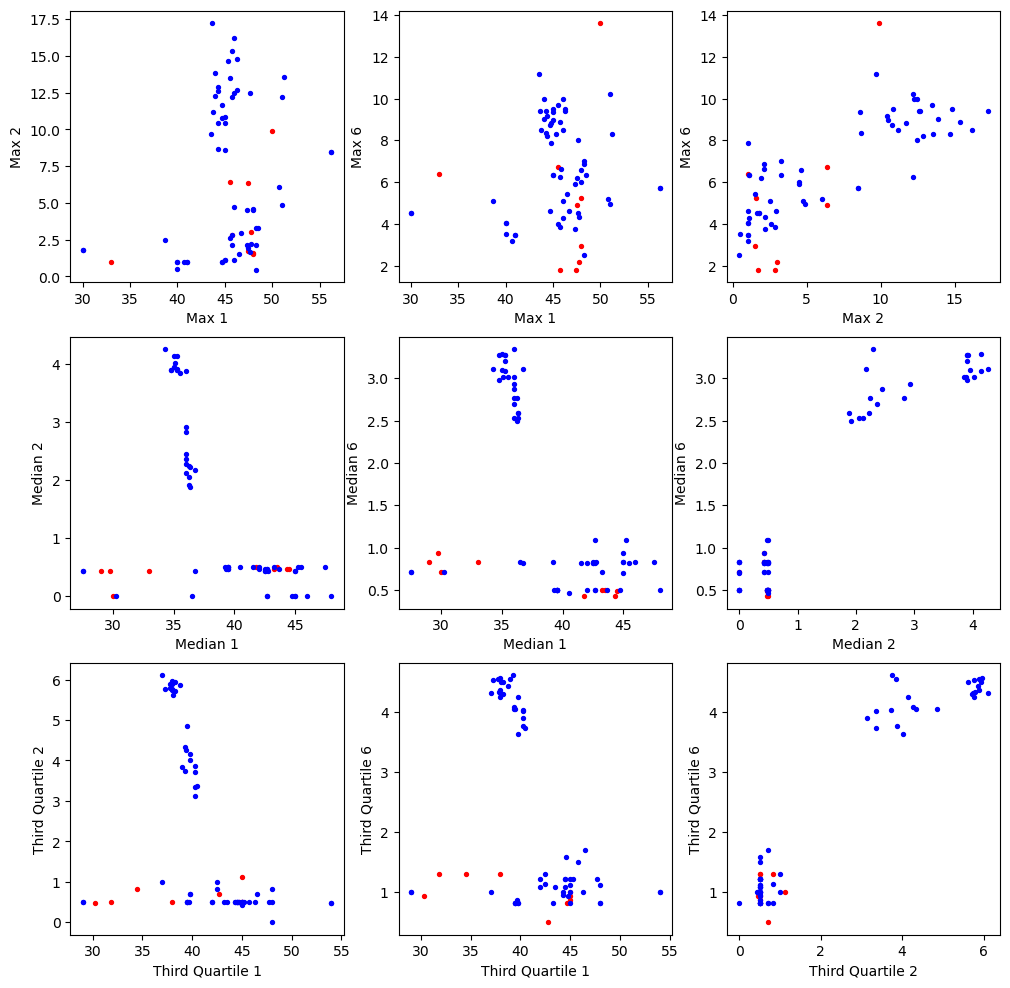

In [8]:
fig, axes = plt.subplots(3, 3, figsize = (12, 12))
# Bending = Red
# Other = Blue

# Max Scatterplots -> First Row
axes[0, 0].scatter(max_1s["bending"], max_2s["bending"], c = "red", s=8)
axes[0, 0].scatter(max_1s["other"], max_2s["other"], c = "blue", s=8)
axes[0, 0].set_xlabel("Max 1")
axes[0, 0].set_ylabel("Max 2")

axes[0, 1].scatter(max_1s["bending"], max_6s["bending"], c = "red", s=8)
axes[0, 1].scatter(max_1s["other"], max_6s["other"], c = "blue", s=8)
axes[0, 1].set_xlabel("Max 1")
axes[0, 1].set_ylabel("Max 6")

axes[0, 2].scatter(max_2s["bending"], max_6s["bending"], c = "red", s=8)
axes[0, 2].scatter(max_2s["other"], max_6s["other"], c = "blue", s=8)
axes[0, 2].set_xlabel("Max 2")
axes[0, 2].set_ylabel("Max 6")

# Median Scatterplots -> Second Row
axes[1, 0].scatter(median_1s["bending"], median_2s["bending"], c = "red", s=8)
axes[1, 0].scatter(median_1s["other"], median_2s["other"], c = "blue", s=8)
axes[1, 0].set_xlabel("Median 1")
axes[1, 0].set_ylabel("Median 2")

axes[1, 1].scatter(median_1s["bending"], median_6s["bending"], c = "red", s=8)
axes[1, 1].scatter(median_1s["other"], median_6s["other"], c = "blue", s=8)
axes[1, 1].set_xlabel("Median 1")
axes[1, 1].set_ylabel("Median 6")

axes[1, 2].scatter(median_2s["bending"], median_6s["bending"], c = "red", s=8)
axes[1, 2].scatter(median_2s["other"], median_6s["other"], c = "blue", s=8)
axes[1, 2].set_xlabel("Median 2")
axes[1, 2].set_ylabel("Median 6")

# Third Quartile Scatterplots -> Third Row
axes[2, 0].scatter(thirdQ_1s["bending"], thirdQ_2s["bending"], c = "red", s=8)
axes[2, 0].scatter(thirdQ_1s["other"], thirdQ_2s["other"], c = "blue", s=8)
axes[2, 0].set_xlabel("Third Quartile 1")
axes[2, 0].set_ylabel("Third Quartile 2")

axes[2, 1].scatter(thirdQ_1s["bending"], thirdQ_6s["bending"], c = "red", s=8)
axes[2, 1].scatter(thirdQ_1s["other"], thirdQ_6s["other"], c = "blue", s=8)
axes[2, 1].set_xlabel("Third Quartile 1")
axes[2, 1].set_ylabel("Third Quartile 6")

axes[2, 2].scatter(thirdQ_2s["bending"], thirdQ_6s["bending"], c = "red", s=8)
axes[2, 2].scatter(thirdQ_2s["other"], thirdQ_6s["other"], c = "blue", s=8)
axes[2, 2].set_xlabel("Third Quartile 2")
axes[2, 2].set_ylabel("Third Quartile 6")

plt.show()

There doesn't seem to be that great of separation between bending and other.

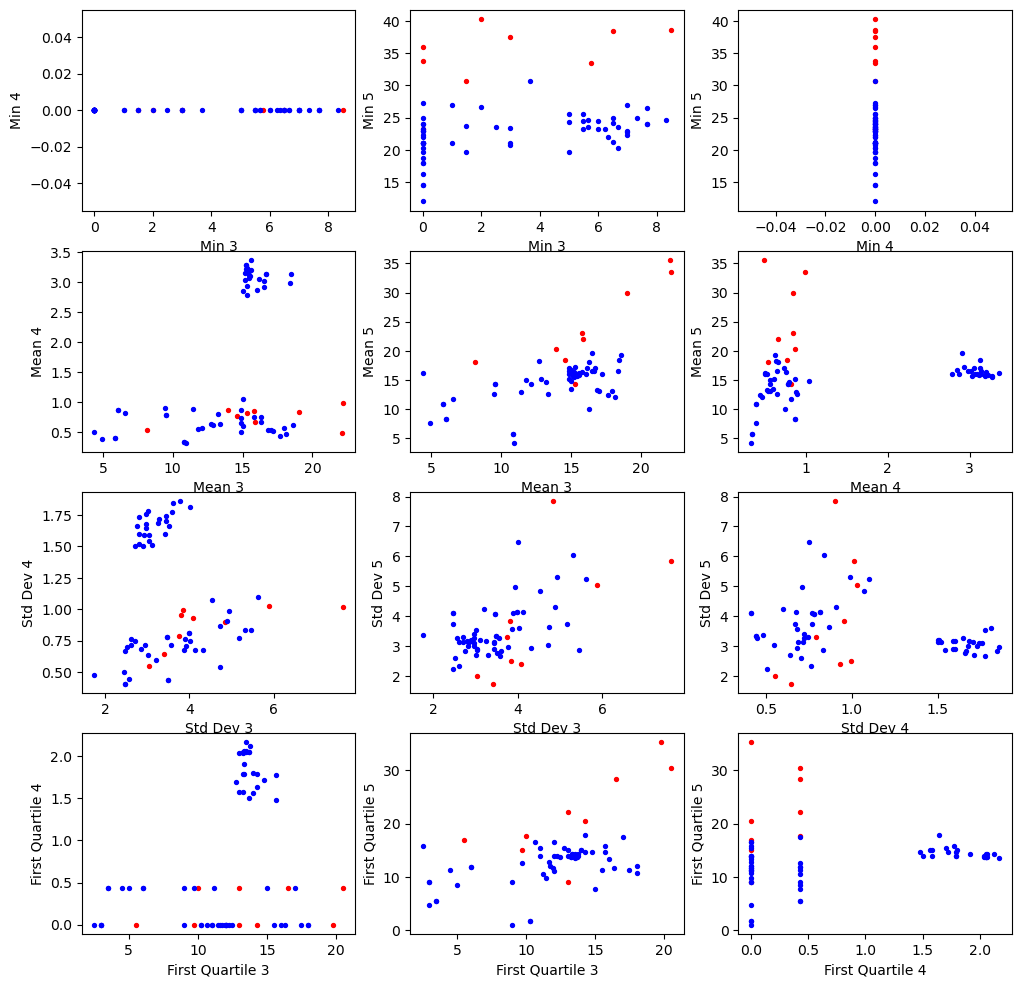

In [9]:
# Trying for the other features as well
# Min, Mean, Std Dev, FirstQ
min_1s = {"bending" : [], "other" : []}
min_2s = {"bending" : [], "other" : []}
min_6s = {"bending" : [], "other" : []}

mean_1s = {"bending" : [], "other" : []}
mean_2s = {"bending" : [], "other" : []}
mean_6s = {"bending" : [], "other" : []}

stddev_1s = {"bending" : [], "other" : []}
stddev_2s = {"bending" : [], "other" : []}
stddev_6s = {"bending" : [], "other" : []}

firstQ_1s = {"bending" : [], "other" : []}
firstQ_2s = {"bending" : [], "other" : []}
firstQ_6s = {"bending" : [], "other" : []}

for _, row in train_feat_df.iterrows(): # _ because we don't care about index, just go through entire thing
    
    file_name = row["dirfile_name"]
    
    if "bend" in file_name:
        activity = "bending"
    else:
        activity = "other"
        
    min_1s[activity].append(row["min_3"])
    min_2s[activity].append(row["min_4"])
    min_6s[activity].append(row["max_5"])

    mean_1s[activity].append(row["mean_3"])
    mean_2s[activity].append(row["mean_4"])
    mean_6s[activity].append(row["mean_5"])

    stddev_1s[activity].append(row["std_dev_3"])
    stddev_2s[activity].append(row["std_dev_4"])
    stddev_6s[activity].append(row["std_dev_5"])

    firstQ_1s[activity].append(row["first_quart_3"])
    firstQ_2s[activity].append(row["first_quart_4"])
    firstQ_6s[activity].append(row["first_quart_5"])

fig, axes = plt.subplots(4, 3, figsize = (12, 12))
# Bending = Red
# Other = Blue

# Min Scatterplots -> First Row
axes[0, 0].scatter(min_1s["bending"], min_2s["bending"], c = "red", s=8)
axes[0, 0].scatter(min_1s["other"], min_2s["other"], c = "blue", s=8)
axes[0, 0].set_xlabel("Min 3")
axes[0, 0].set_ylabel("Min 4")

axes[0, 1].scatter(min_1s["bending"], min_6s["bending"], c = "red", s=8)
axes[0, 1].scatter(min_1s["other"], min_6s["other"], c = "blue", s=8)
axes[0, 1].set_xlabel("Min 3")
axes[0, 1].set_ylabel("Min 5")

axes[0, 2].scatter(min_2s["bending"], min_6s["bending"], c = "red", s=8)
axes[0, 2].scatter(min_2s["other"], min_6s["other"], c = "blue", s=8)
axes[0, 2].set_xlabel("Min 4")
axes[0, 2].set_ylabel("Min 5")

# Mean Scatterplots -> Second Row
axes[1, 0].scatter(mean_1s["bending"], mean_2s["bending"], c = "red", s=8)
axes[1, 0].scatter(mean_1s["other"], mean_2s["other"], c = "blue", s=8)
axes[1, 0].set_xlabel("Mean 3")
axes[1, 0].set_ylabel("Mean 4")

axes[1, 1].scatter(mean_1s["bending"], mean_6s["bending"], c = "red", s=8)
axes[1, 1].scatter(mean_1s["other"], mean_6s["other"], c = "blue", s=8)
axes[1, 1].set_xlabel("Mean 3")
axes[1, 1].set_ylabel("Mean 5")

axes[1, 2].scatter(mean_2s["bending"], mean_6s["bending"], c = "red", s=8)
axes[1, 2].scatter(mean_2s["other"], mean_6s["other"], c = "blue", s=8)
axes[1, 2].set_xlabel("Mean 4")
axes[1, 2].set_ylabel("Mean 5")

# Std Dev Scatterplots -> Third Row
axes[2, 0].scatter(stddev_1s["bending"], stddev_2s["bending"], c = "red", s=8)
axes[2, 0].scatter(stddev_1s["other"], stddev_2s["other"], c = "blue", s=8)
axes[2, 0].set_xlabel("Std Dev 3")
axes[2, 0].set_ylabel("Std Dev 4")

axes[2, 1].scatter(stddev_1s["bending"], stddev_6s["bending"], c = "red", s=8)
axes[2, 1].scatter(stddev_1s["other"], stddev_6s["other"], c = "blue", s=8)
axes[2, 1].set_xlabel("Std Dev 3")
axes[2, 1].set_ylabel("Std Dev 5")

axes[2, 2].scatter(stddev_2s["bending"], stddev_6s["bending"], c = "red", s=8)
axes[2, 2].scatter(stddev_2s["other"], stddev_6s["other"], c = "blue", s=8)
axes[2, 2].set_xlabel("Std Dev 4")
axes[2, 2].set_ylabel("Std Dev 5")

# First Quartile Scatterplots -> Fourth Row
axes[3, 0].scatter(firstQ_1s["bending"], firstQ_2s["bending"], c = "red", s=8)
axes[3, 0].scatter(firstQ_1s["other"], firstQ_2s["other"], c = "blue", s=8)
axes[3, 0].set_xlabel("First Quartile 3")
axes[3, 0].set_ylabel("First Quartile 4")

axes[3, 1].scatter(firstQ_1s["bending"], firstQ_6s["bending"], c = "red", s=8)
axes[3, 1].scatter(firstQ_1s["other"], firstQ_6s["other"], c = "blue", s=8)
axes[3, 1].set_xlabel("First Quartile 3")
axes[3, 1].set_ylabel("First Quartile 5")

axes[3, 2].scatter(firstQ_2s["bending"], firstQ_6s["bending"], c = "red", s=8)
axes[3, 2].scatter(firstQ_2s["other"], firstQ_6s["other"], c = "blue", s=8)
axes[3, 2].set_xlabel("First Quartile 4")
axes[3, 2].set_ylabel("First Quartile 5")

plt.show()
    

Something to Note:
- For min, mean, std dev, and first quartile for 1, 2, and 6 the separation isn't great either.
- HOWEVER, when I changed out 1, 2, and 6 for 3, 4, and 5 there is clearly better separation (as shown above).
- - This happens for max, median, and third quartile as well (the three features I chose), but I left those scatterplots as is since the question asks for 1, 2, and 6, but I just want to point out that 3, 4, and 5 gives better separation across ALL the features.